# Project 2
# Participez à un concours sur la Smart City

* **Données**
  - téléchargez le jeu de données des arbres de la ville de Paris.
* **Règles du challenge**
   - installez votre environnement de développement sur votre ordinateur, et créez un environnement virtuel dédié à ce challenge.
   - Les données doivent être explorées à l’aide de Python et de ses librairies.
   - Vous soumettrez votre analyse sous forme de présentation, contenant les informations suivantes :
        * Présentation générale du jeu de données
        * Démarche méthodologique d’analyse de données
        * Synthèse de l’analyse de données
    - Le second livrable prendra la forme d’un Notebook Jupyter. Le Notebook sera documenté pour expliciter les différents traitements, calculs ou graphiques que vous effectuez en utilisant les fonctionnalités d’édition de texte de Jupyter. Vos explications doivent permettre à un public non technique de comprendre les différentes étapes de votre analyse et votre synthèse.

# Partie 1. Accès aux données
Les données se trouvent sur le disque local à l'emplacement suivant :  
`C:\Users\darya\Desktop\OpenClassRooms\Project 02`
## 1. Chargement des données
Nous utilisons Python pour lire les fichiers situés dans ce dossier.
## Exemple de code pour lire les données
```python
import pandas as pd
import os
# Chemin vers le dossier contenant les fichiers
chemin_dossier = r"C:\Users\darya\Desktop\OpenClassRooms\Project 02"
# Exemple de lecture d'un fichier CSV
nom_fichier = "p2-arbres-fr.csv"  # Remplacez par le nom de votre fichier
chemin_fichier = os.path.join(chemin_dossier, nom_fichier)
# Lecture des données
donnees = pd.read_csv(chemin_fichier)
print(donnees.head())

In [2]:
import pandas as pd
import os

# Chemin vers le dossier contenant les fichiers
chemin_dossier = r"C:\Users\darya\Desktop\OpenClassRooms\Project 02"

# Exemple de lecture d'un fichier CSV
nom_fichier = "p2-arbres-fr.csv"  # Remplacez par le nom de votre fichier
chemin_fichier = os.path.join(chemin_dossier, nom_fichier)

# Lecture des données
df = pd.read_csv(chemin_fichier, sep=";")
df.head()

,id,type_emplacement,domanialite,arrondissement,complement_addresse,numero,lieu,id_emplacement,libelle_francais,genre,espece,variete,circonference_cm,hauteur_m,stade_developpement,remarquable,geo_point_2d_a,geo_point_2d_b
0,99874,Arbre,Jardin,PARIS 7E ARRDT,NaN,NaN,MAIRIE DU 7E 116 RUE DE GRENELLE PARIS 7E,19,Marronnier,Aesculus,hippocastanum,NaN,20,5,NaN,0.0,48.857620,2.320962
1,99875,Arbre,Jardin,PARIS 7E ARRDT,NaN,NaN,MAIRIE DU 7E 116 RUE DE GRENELLE PARIS 7E,20,If,Taxus,baccata,NaN,65,8,A,NaN,48.857656,2.321031
2,99876,Arbre,Jardin,PARIS 7E ARRDT,NaN,NaN,MAIRIE DU 7E 116 RUE DE GRENELLE PARIS 7E,21,If,Taxus,baccata,NaN,90,10,A,NaN,48.857705,2.321061
3,99877,Arbre,Jardin,PARIS 7E ARRDT,NaN,NaN,MAIRIE DU 7E 116 RUE DE GRENELLE PARIS 7E,22,Erable,Acer,negundo,NaN,60,8,A,NaN,48.857722,2.321006
4,99878,Arbre,Jardin,PARIS 17E ARRDT,NaN,NaN,PARC CLICHY-BATIGNOLLES-MARTIN LUTHER KING,000G0037,Arbre à miel,Tetradium,daniellii,NaN,38,0,NaN,NaN,48.890435,2.315289


In [3]:
# Détermination des types de données
df.dtypes

id                       int64
type_emplacement        object
domanialite             object
arrondissement          object
complement_addresse     object
numero                 float64
lieu                    object
id_emplacement          object
libelle_francais        object
genre                   object
espece                  object
variete                 object
circonference_cm         int64
hauteur_m                int64
stade_developpement     object
remarquable            float64
geo_point_2d_a         float64
geo_point_2d_b         float64
dtype: object

In [4]:
# Obtenir des informations générales sur le DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200137 entries, 0 to 200136
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   200137 non-null  int64  
 1   type_emplacement     200137 non-null  object 
 2   domanialite          200136 non-null  object 
 3   arrondissement       200137 non-null  object 
 4   complement_addresse  30902 non-null   object 
 5   numero               0 non-null       float64
 6   lieu                 200137 non-null  object 
 7   id_emplacement       200137 non-null  object 
 8   libelle_francais     198640 non-null  object 
 9   genre                200121 non-null  object 
 10  espece               198385 non-null  object 
 11  variete              36777 non-null   object 
 12  circonference_cm     200137 non-null  int64  
 13  hauteur_m            200137 non-null  int64  
 14  stade_developpement  132932 non-null  object 
 15  remarquable      

In [5]:
# Taille et aperçu des données
print(df.shape)             # Dimensions (lignes, colonnes)
columnsName = df.columns    # Liste des colonnes

(200137, 18)


In [6]:
# Nombre de valeurs manquantes par colonne
valeurs_manquantes = df.isnull().sum()
print(valeurs_manquantes)

id                          0
type_emplacement            0
domanialite                 1
arrondissement              0
complement_addresse    169235
numero                 200137
lieu                        0
id_emplacement              0
libelle_francais         1497
genre                      16
espece                   1752
variete                163360
circonference_cm            0
hauteur_m                   0
stade_developpement     67205
remarquable             63098
geo_point_2d_a              0
geo_point_2d_b              0
dtype: int64


In [7]:
# Pourcentage de valeurs manquantes par colonne
pourcentage_manquantes = (df.isnull().sum() / len(df)) * 100
print(pourcentage_manquantes)

id                       0.000000
type_emplacement         0.000000
domanialite              0.000500
arrondissement           0.000000
complement_addresse     84.559577
numero                 100.000000
lieu                     0.000000
id_emplacement           0.000000
libelle_francais         0.747988
genre                    0.007995
espece                   0.875400
variete                 81.624088
circonference_cm         0.000000
hauteur_m                0.000000
stade_developpement     33.579498
remarquable             31.527404
geo_point_2d_a           0.000000
geo_point_2d_b           0.000000
dtype: float64


In [8]:
# Colonnes avec des valeurs manquantes uniquement
colonnes_manquantes = df.columns[df.isnull().any()]
print("Colonnes avec des valeurs manquantes :", colonnes_manquantes)

Colonnes avec des valeurs manquantes : Index(['domanialite', 'complement_addresse', 'numero', 'libelle_francais',
       'genre', 'espece', 'variete', 'stade_developpement', 'remarquable'],
      dtype='object')


<Axes: >

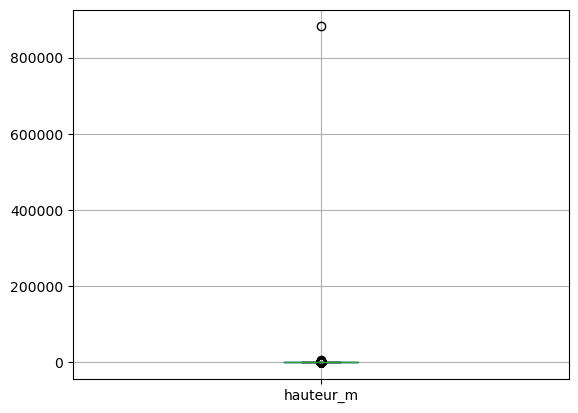

In [10]:
df[['hauteur_m']].boxplot()

In [11]:
max_value = df['hauteur_m'].max()
print("The maximum value is:", max_value)

The maximum value is: 881818


In [12]:
# Calculate the 99th percentile
percentile_99 = df['hauteur_m'].quantile(0.99)

# Filter out rows where 'hauteur_m' is less than or equal to the 99th percentile
filtered_df = df[df['hauteur_m'] <= percentile_99]

print("Filtered DataFrame:")
print(filtered_df)


Filtered DataFrame:
             id type_emplacement domanialite     arrondissement  \
0         99874            Arbre      Jardin     PARIS 7E ARRDT   
1         99875            Arbre      Jardin     PARIS 7E ARRDT   
2         99876            Arbre      Jardin     PARIS 7E ARRDT   
3         99877            Arbre      Jardin     PARIS 7E ARRDT   
4         99878            Arbre      Jardin    PARIS 17E ARRDT   
...         ...              ...         ...                ...   
200132  2024741            Arbre      Jardin  BOIS DE VINCENNES   
200133  2024742            Arbre      Jardin  BOIS DE VINCENNES   
200134  2024743            Arbre      Jardin  BOIS DE VINCENNES   
200135  2024744            Arbre      Jardin  BOIS DE VINCENNES   
200136  2024745            Arbre      Jardin  BOIS DE VINCENNES   

       complement_addresse  numero  \
0                      NaN     NaN   
1                      NaN     NaN   
2                      NaN     NaN   
3                      

In [15]:
filtered_df[['hauteur_m']].boxplot()

<Axes: >

https://stacklima.com/cellule-markdown-dans-le-bloc-notes-jupyter/